# AI4I 2020 Predictive Maintenance Dataset
## Data Cleaning and Exploratory Data Analysis

### Objective
The goal of this notebook is to understand the AI4I 2020 Predictive Maintenance dataset before building machine learning models.

This notebook performs:

- Data loading
- Data quality assessment
- Missing value analysis
- Duplicate detection
- Statistical summaries
- Exploratory Data Analysis (EDA)
- Outlier detection
- Feature relationship analysis
- Business insights

Understanding the data helps identify important patterns related to machine failures and provides a strong foundation for predictive maintenance modeling.

In [1]:
# ==========================================
# Import Required Libraries
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
# ==========================================
# Load Dataset
# ==========================================

df = pd.read_csv("../data/ai4i2020.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [3]:
# ==========================================
# Dataset Shape
# ==========================================

print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 10000
Columns : 14


In [6]:
# First Five Records

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [7]:
# Last Five Records

df.tail()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
9995,9996,M24855,M,298.8,308.4,1604,29.5,14,0,0,0,0,0,0
9996,9997,H39410,H,298.9,308.4,1632,31.8,17,0,0,0,0,0,0
9997,9998,M24857,M,299.0,308.6,1645,33.4,22,0,0,0,0,0,0
9998,9999,H39412,H,299.0,308.7,1408,48.5,25,0,0,0,0,0,0
9999,10000,M24859,M,299.0,308.7,1500,40.2,30,0,0,0,0,0,0


In [8]:
# Random Sample

df.sample(5, random_state=42)

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
6252,6253,L53432,L,300.8,310.3,1538,36.1,198,0,0,0,0,0,0
4684,4685,M19544,M,303.6,311.8,1421,44.8,101,1,0,0,0,0,0
1731,1732,M16591,M,298.3,307.9,1485,42.0,117,0,0,0,0,0,0
4742,4743,L51922,L,303.3,311.3,1592,33.7,14,0,0,0,0,0,0
4521,4522,L51701,L,302.4,310.4,1865,23.9,129,0,0,0,0,0,0


In [9]:
# Dataset Information

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [10]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [11]:
# Data Types

df.dtypes

UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

In [12]:
# Missing Values

missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": (missing/len(df))*100
})

missing_df

,Missing Values,Percentage
UDI,0,0.0
Product ID,0,0.0
Type,0,0.0
Air temperature [K],0,0.0
Process temperature [K],0,0.0
Rotational speed [rpm],0,0.0
Torque [Nm],0,0.0
Tool wear [min],0,0.0
Machine failure,0,0.0
TWF,0,0.0


In [13]:
# Duplicate Records

duplicates = df.duplicated().sum()

print("Duplicate Rows :", duplicates)

# Unique Values

pd.DataFrame({
    "Unique Values": df.nunique()
})

Duplicate Rows : 0


,Unique Values
UDI,10000
Product ID,10000
Type,3
Air temperature [K],93
Process temperature [K],82
Rotational speed [rpm],941
Torque [Nm],577
Tool wear [min],246
Machine failure,2
TWF,2


# Exploratory Data Analysis (EDA)

EDA helps us understand the characteristics of the dataset and identify meaningful patterns related to machine failures.

The following visualizations focus on:

- Failure distribution
- Product categories
- Feature distributions
- Outliers
- Correlations
- Feature behaviour during failures

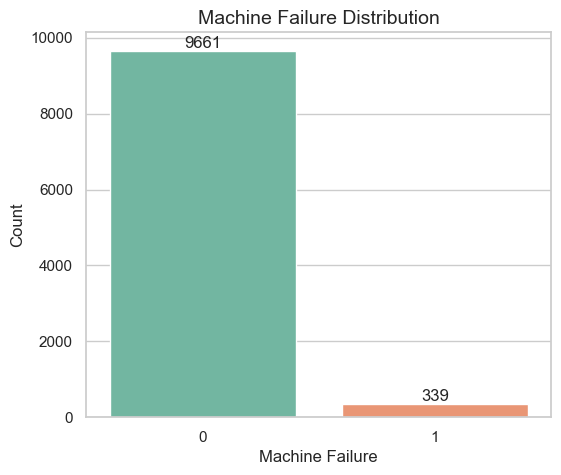

In [17]:
# ==========================================
# Machine Failure Distribution
# ==========================================

plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="Machine failure",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Machine Failure Distribution", fontsize=14)
plt.xlabel("Machine Failure")
plt.ylabel("Count")

plt.show()

### Insight

- The dataset is highly imbalanced.
- Most machines operate without failure.
- This imbalance indicates that accuracy alone is not an appropriate evaluation metric.
- Precision, Recall, F1-score, and PR-AUC are more suitable for predictive maintenance problems.

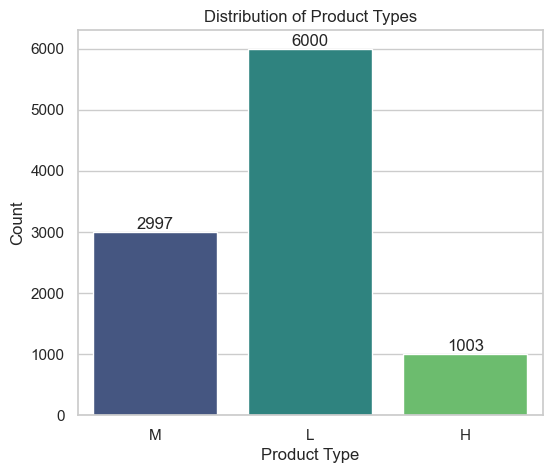

In [18]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="Type",
    palette="viridis"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Distribution of Product Types")
plt.xlabel("Product Type")
plt.ylabel("Count")

plt.show()

### Insight

The dataset contains three product categories:

- L (Low)
- M (Medium)
- H (High)

Understanding the distribution helps determine whether machine failures are associated with specific product categories.

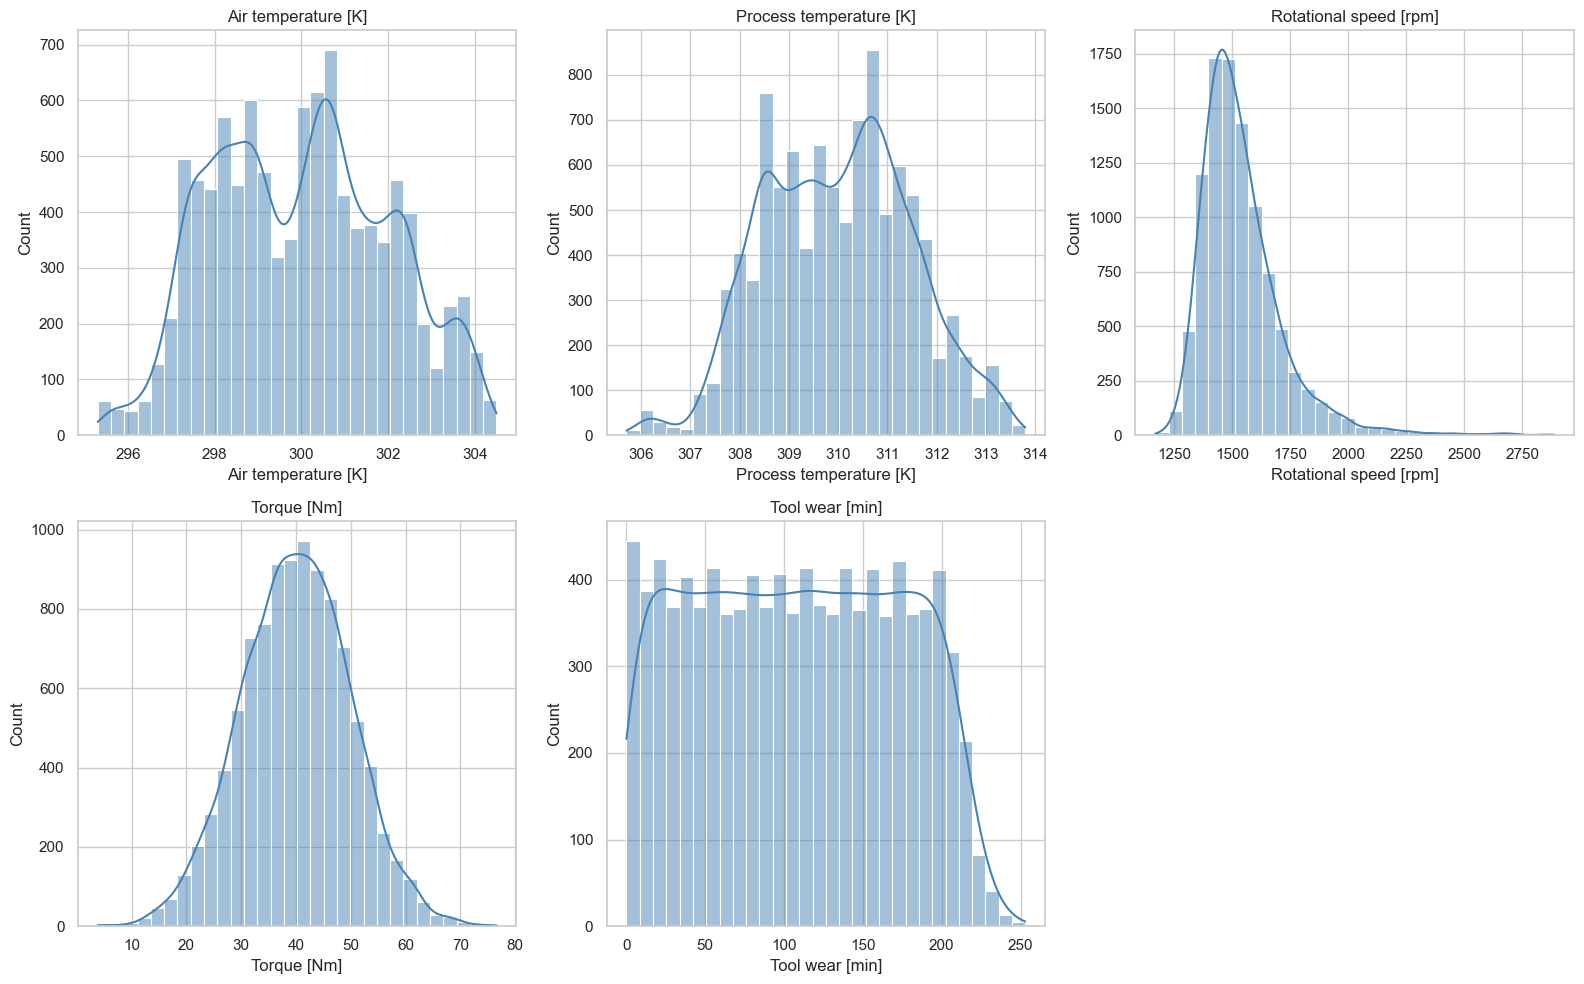

In [19]:
numeric_cols = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

fig, axes = plt.subplots(2,3, figsize=(16,10))

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    
    sns.histplot(
        df[col],
        bins=30,
        kde=True,
        ax=axes[i],
        color="steelblue"
    )
    
    axes[i].set_title(col)

fig.delaxes(axes[-1])

plt.tight_layout()

plt.show()

### Insight

The numerical features exhibit different distributions:

- Temperature variables are approximately normally distributed.
- Tool wear shows a wider spread.
- Rotational speed and torque display operating variability that may influence machine failures.

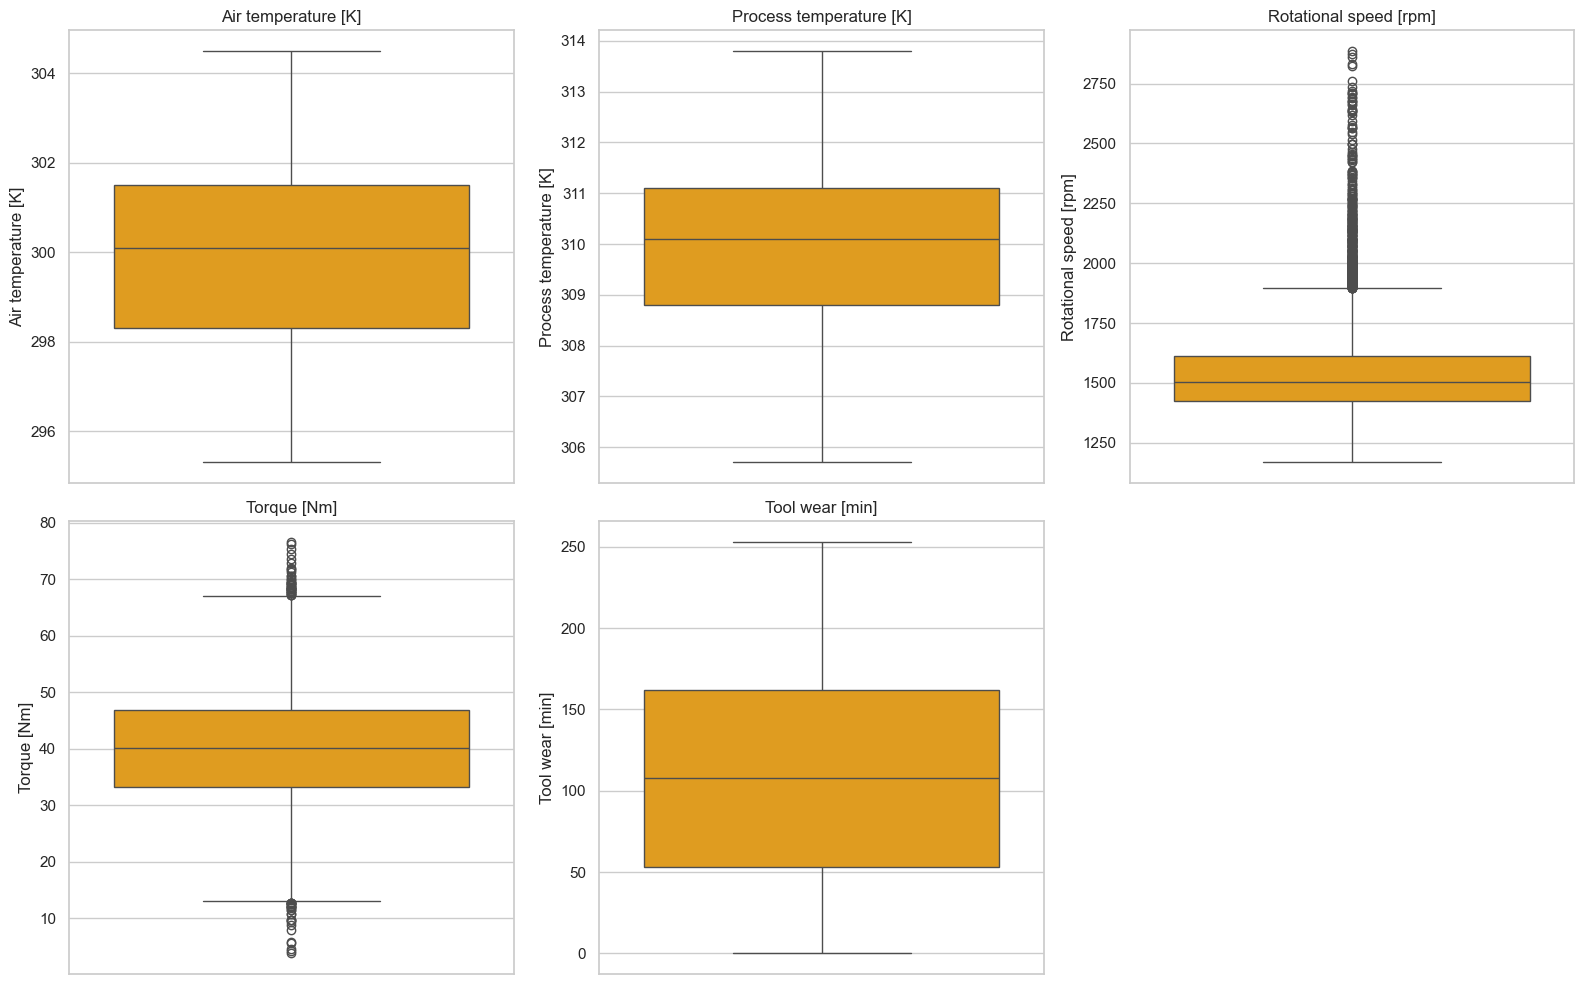

In [20]:
fig, axes = plt.subplots(2,3, figsize=(16,10))

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    
    sns.boxplot(
        y=df[col],
        ax=axes[i],
        color="orange"
    )
    
    axes[i].set_title(col)

fig.delaxes(axes[-1])

plt.tight_layout()

plt.show()

### Insight

Several numerical features contain outliers.

In predictive maintenance, these values may represent unusual operating conditions rather than data errors.

Therefore, outliers should be investigated before removal.

In [21]:
# Save cleaned dataset
df.to_csv("../data/ai4i2020_clean.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Correlation Analysis

Understanding correlations between numerical features helps identify relationships and potential redundancy among variables.

It also provides insight into which sensor measurements tend to vary together.

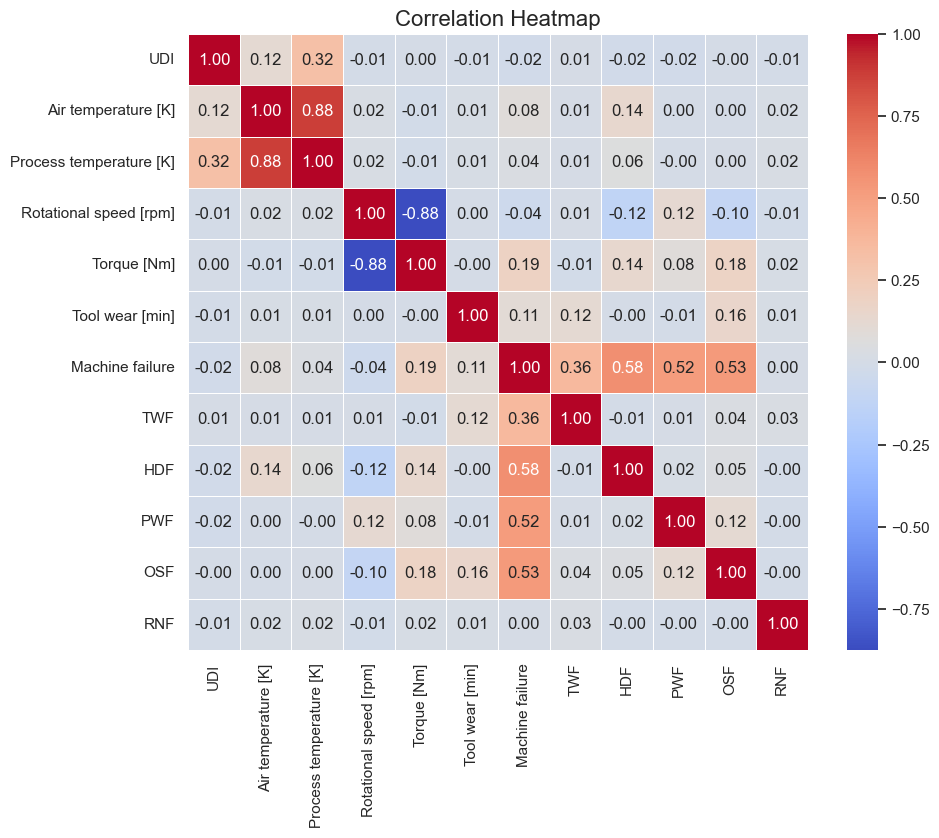

In [22]:
# ==========================================
# Correlation Heatmap
# ==========================================

plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)

plt.show()

### Insight

- Air Temperature and Process Temperature show a strong positive correlation.
- Torque and Rotational Speed exhibit a moderate negative relationship.
- Machine Failure has relatively low linear correlation with individual features, suggesting that combinations of variables may better explain failures.

# Sensor Behaviour During Failures

The following plots compare sensor measurements between failed and non-failed machines.

This helps identify which operational parameters are associated with failures.

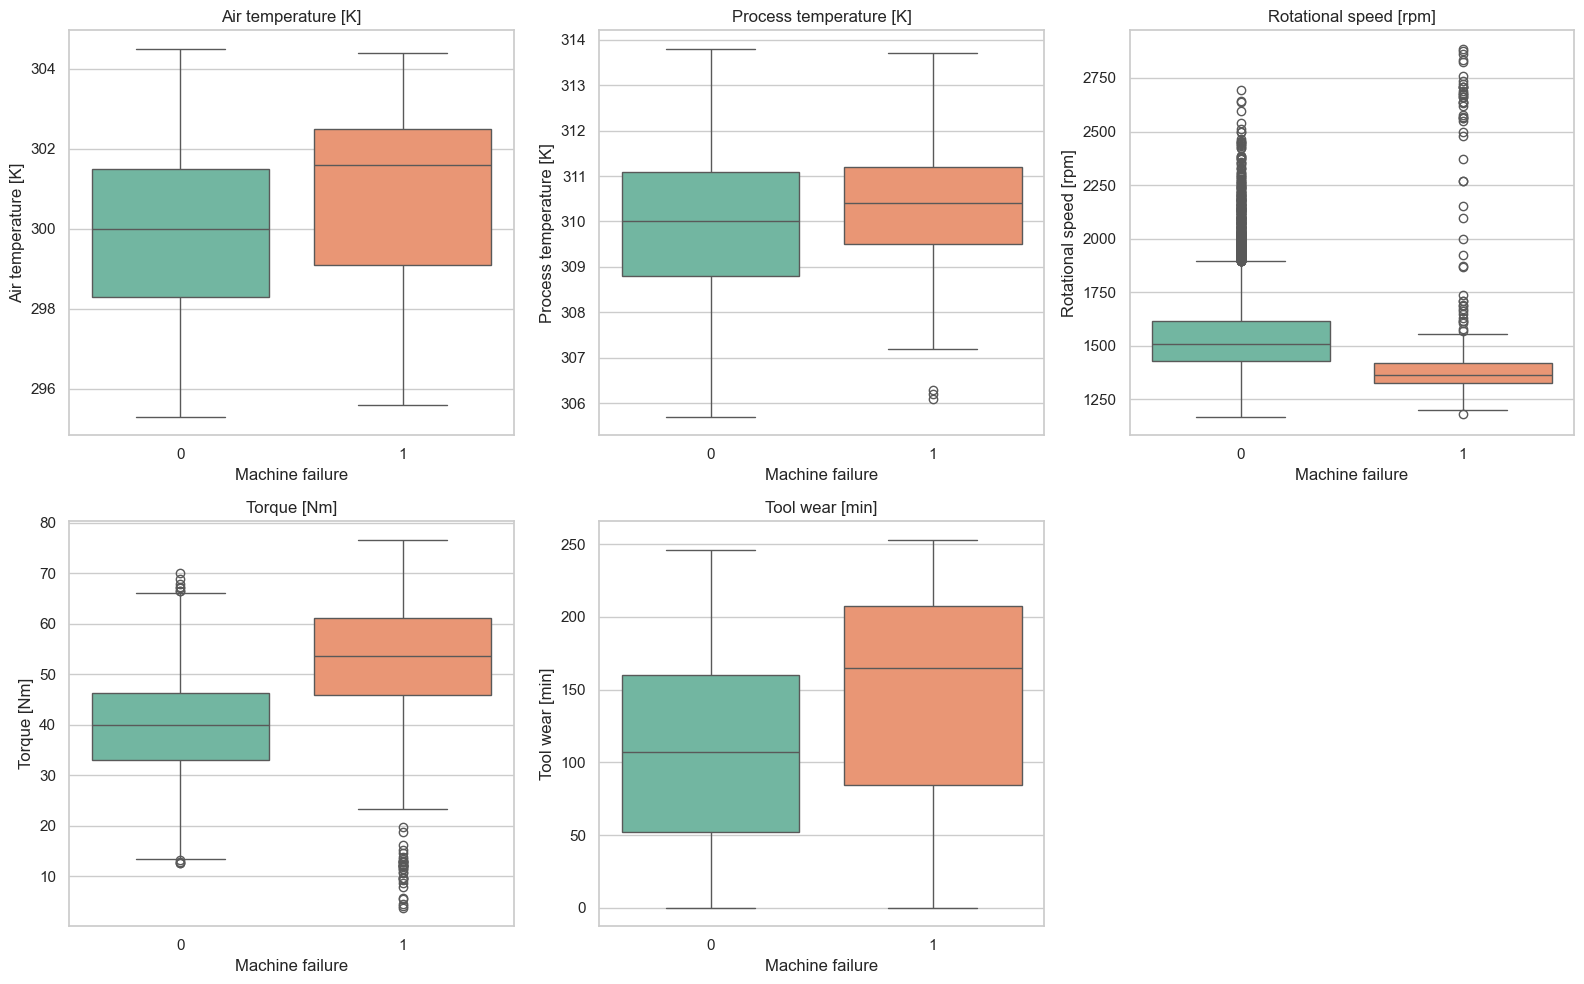

In [23]:
important_features = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]"
]

fig, axes = plt.subplots(2,3, figsize=(16,10))

axes = axes.flatten()

for i, col in enumerate(important_features):

    sns.boxplot(
        data=df,
        x="Machine failure",
        y=col,
        palette="Set2",
        ax=axes[i]
    )

    axes[i].set_title(col)

fig.delaxes(axes[-1])

plt.tight_layout()

plt.show()

### Insight

- Failed machines generally exhibit higher torque and tool wear.
- Rotational speed also shows noticeable differences between normal and failed machines.
- These variables are expected to be important predictors for machine failure.

# Machine Failure Across Product Categories

This visualization compares machine failures among Low (L), Medium (M), and High (H) quality products.

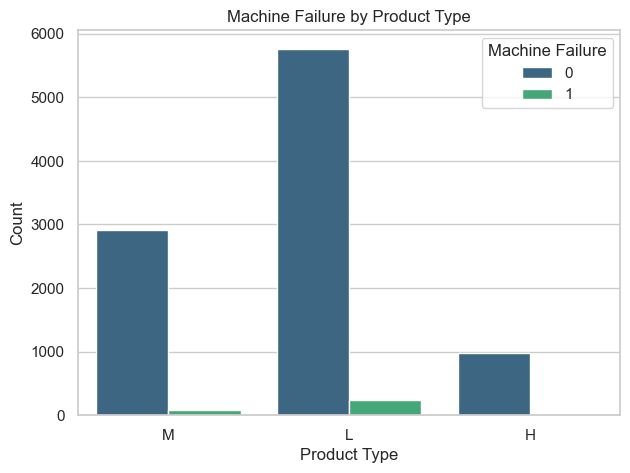

In [24]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Type",
    hue="Machine failure",
    palette="viridis"
)

plt.title("Machine Failure by Product Type")

plt.xlabel("Product Type")

plt.ylabel("Count")

plt.legend(title="Machine Failure")

plt.show()

### Insight

Failure occurrences vary across product categories.

This information may help maintenance teams prioritize inspection strategies for different machine groups.

# Feature Correlation with Target

This analysis measures the correlation between numerical features and the Machine Failure target.

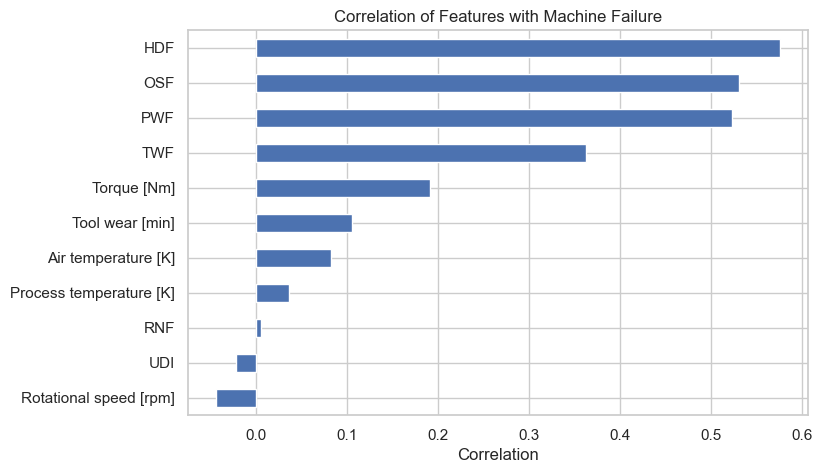

In [25]:
corr_target = corr["Machine failure"].drop("Machine failure")

corr_target = corr_target.sort_values()

plt.figure(figsize=(8,5))

corr_target.plot(
    kind="barh"
)

plt.title("Correlation of Features with Machine Failure")

plt.xlabel("Correlation")

plt.grid(True)

plt.show()

### Insight

Although individual correlations are relatively small, torque, tool wear, and rotational speed show stronger relationships with machine failures than temperature variables.

This indicates that predictive models should learn interactions among multiple features rather than relying on a single sensor.

# Key Business Insights

Based on the exploratory data analysis, the following observations were made:

- The dataset is highly imbalanced, with significantly fewer failure cases than normal operations.
- No missing values or duplicate records were found, indicating high data quality.
- Torque, rotational speed, and tool wear exhibit stronger relationships with machine failures.
- Temperature features are highly correlated with one another, reflecting expected machine operating conditions.
- Product categories show varying failure frequencies, suggesting maintenance strategies may differ across machine types.
- Outliers are likely to represent extreme operating conditions rather than data errors and should be retained for predictive maintenance modeling.

These findings provide a strong foundation for feature engineering and machine learning model development.

In [26]:
# ==========================================
# Export Clean Dataset
# ==========================================

df.to_csv("../data/ai4i2020_clean.csv", index=False)

print("="*50)
print("Data Cleaning and EDA Completed Successfully!")
print("Clean dataset saved as: ai4i2020_clean.csv")
print("="*50)

Data Cleaning and EDA Completed Successfully!
Clean dataset saved as: ai4i2020_clean.csv
